# EDA - Dataset Hillstrom (uplift-retention-model)

Este notebook explora el dataset Hillstrom antes de entrenar los modelos de uplift.

Preguntas que queremos responder:
1. ¿Qué columnas tiene el dataset y qué significan?
2. ¿Cómo se distribuyen los clientes entre tratamiento (recibió email) y control (no recibió email)?
3. ¿Cuál es la tasa de conversión (compra) en cada grupo, y qué tan grande es la diferencia bruta entre ambos?

Fuente original del dataset: http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_raw_data, build_treatment_and_outcome, TREATMENT_COL, OUTCOME_COL

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = load_raw_data("../data/raw/hillstrom.csv")
print(df.shape)
df.head()

(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 1. Diccionario de columnas

| Columna | Significado |
|---|---|
| `recency` | Meses desde la última compra del cliente |
| `history_segment` | Bucket categórico del gasto histórico del cliente (ej. "2) $100 - $200") |
| `history` | Gasto histórico real del cliente en dólares |
| `mens` | 1 si el cliente compró ropa de hombre en los últimos 12 meses |
| `womens` | 1 si el cliente compró ropa de mujer en los últimos 12 meses |
| `zip_code` | Clasificación de la zona: Rural / Suburban / Urban |
| `newbie` | 1 si el cliente es nuevo (se registró en los últimos 12 meses) |
| `channel` | Canal de compra histórico del cliente: Phone / Web / Multichannel |
| `segment` | **Grupo experimental original**: "Mens E-Mail", "Womens E-Mail" o "No E-Mail" |
| `visit` | 1 si el cliente visitó el sitio en las 2 semanas posteriores a la campaña |
| `conversion` | **Outcome principal de este proyecto**: 1 si el cliente compró en las 2 semanas posteriores |
| `spend` | Monto gastado en esas 2 semanas (0 si no compró) |

Para este proyecto usamos `conversion` como outcome y colapsamos `segment` en un
treatment binario (`1` = recibió algún email, `0` = no recibió email). Ver
`src/preprocessing.py::build_treatment_and_outcome` para el detalle y el porqué
de esa simplificación.

In [3]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recency,64000.0,NaN,NaN,NaN,5.763734,3.507592,1.0,2.0,6.0,9.0,12.0
history_segment,64000,7,1) $0 - $100,22970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
history,64000.0,NaN,NaN,NaN,242.085656,256.158608,29.99,64.66,158.11,325.6575,3345.93
mens,64000.0,NaN,NaN,NaN,0.551031,0.497393,0.0,0.0,1.0,1.0,1.0
womens,64000.0,NaN,NaN,NaN,0.549719,0.497526,0.0,0.0,1.0,1.0,1.0
zip_code,64000,3,Surburban,28776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
newbie,64000.0,NaN,NaN,NaN,0.50225,0.499999,0.0,0.0,1.0,1.0,1.0
channel,64000,3,Web,28217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,64000,3,Womens E-Mail,21387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit,64000.0,NaN,NaN,NaN,0.146781,0.35389,0.0,0.0,0.0,0.0,1.0


## 2. Distribución de tratamiento / control

El experimento original tiene 3 brazos. Los colapsamos en 2 (tratamiento vs. control)
porque el objetivo de este proyecto es un uplift modeling binario.

In [4]:
print("Grupos originales (segment):")
print(df["segment"].value_counts())
print("\nProporción:")
print(df["segment"].value_counts(normalize=True))

df_ready = build_treatment_and_outcome(df)

print("\nTreatment binario (1 = recibió email, 0 = control):")
print(df_ready[TREATMENT_COL].value_counts())
print(df_ready[TREATMENT_COL].value_counts(normalize=True))

Grupos originales (segment):
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Proporción:
segment
Womens E-Mail    0.334172
Mens E-Mail      0.332922
No E-Mail        0.332906
Name: proportion, dtype: float64

Treatment binario (1 = recibió email, 0 = control):
treatment
1    42694
0    21306
Name: count, dtype: int64
treatment
1    0.667094
0    0.332906
Name: proportion, dtype: float64


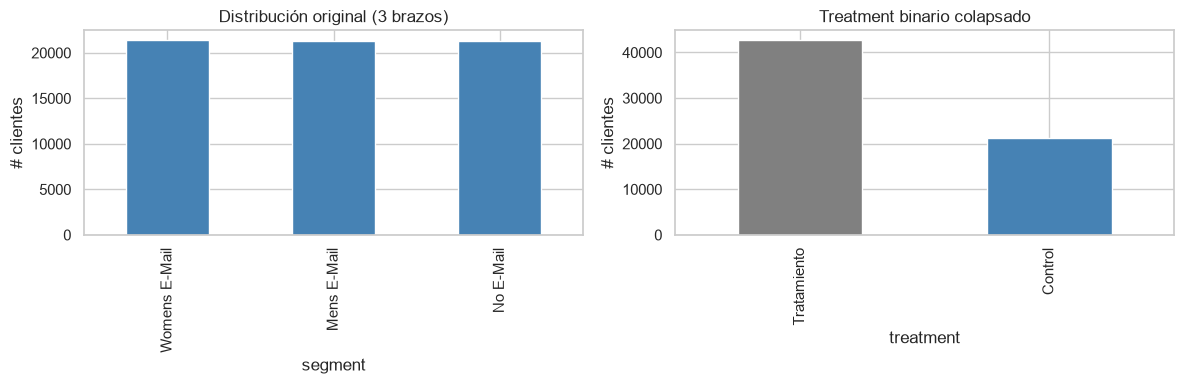

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["segment"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución original (3 brazos)")
axes[0].set_ylabel("# clientes")

df_ready[TREATMENT_COL].value_counts().rename({0: "Control", 1: "Tratamiento"}).plot(
    kind="bar", ax=axes[1], color=["gray", "steelblue"]
)
axes[1].set_title("Treatment binario colapsado")
axes[1].set_ylabel("# clientes")

plt.tight_layout()
plt.show()

**Observación clave**: el grupo de tratamiento (~67%) es el doble del grupo de
control (~33%). Este desbalance es exactamente la razón por la que, más adelante,
el X-Learner debería comportarse mejor que el T-Learner (ver `src/models.py`).

## 3. Tasa de conversión por grupo

Esta es la comparación más importante del EDA: la diferencia "bruta" (naive) de
tasas de conversión entre tratados y control es una primera estimación (muy
ruidosa y sin segmentar) del ATE (Average Treatment Effect).

In [6]:
tasa_por_grupo = df.groupby("segment")[["visit", "conversion", "spend"]].mean()
print(tasa_por_grupo)

tasa_binaria = df_ready.groupby(TREATMENT_COL)[OUTCOME_COL].mean()
print("\nTasa de conversión, treatment binario:")
print(tasa_binaria)

ate_naive = tasa_binaria[1] - tasa_binaria[0]
print(f"\nATE naive (diferencia bruta de conversión tratado vs control): {ate_naive:.4%}")

                  visit  conversion     spend
segment                                      
Mens E-Mail    0.182757    0.012531  1.422617
No E-Mail      0.106167    0.005726  0.652789
Womens E-Mail  0.151400    0.008837  1.077202

Tasa de conversión, treatment binario:
treatment
0    0.005726
1    0.010681
Name: conversion, dtype: float64

ATE naive (diferencia bruta de conversión tratado vs control): 0.4955%


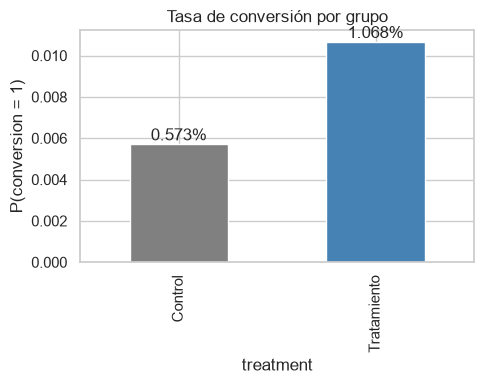

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
tasa_binaria.rename({0: "Control", 1: "Tratamiento"}).plot(
    kind="bar", ax=ax, color=["gray", "steelblue"]
)
ax.set_title("Tasa de conversión por grupo")
ax.set_ylabel("P(conversion = 1)")
for i, v in enumerate(tasa_binaria):
    ax.text(i, v, f"{v:.3%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Nota importante**: esta diferencia bruta (~0.8pp) es un promedio sobre toda
la población y NO nos dice nada sobre qué clientes específicos son más
"persuadibles" por el email. Un cliente que iba a comprar de todas formas
(o uno que nunca va a comprar pase lo que pase) diluyen esa señal. Ese es
justamente el problema que el uplift modeling (S/T/X-Learner) intenta resolver
a nivel individual, en lugar de a nivel de promedio poblacional.

## 4. Conversión y evento raro: por qué importa para el split

`conversion` ocurre en menos del 1% de los clientes. Esto hace que el test set
pueda terminar con muy pocas conversiones si no se hace un split cuidadoso, y
es una de las razones (junto al desbalance de treatment) por las que
`preprocessing.py` estratifica el split combinando treatment + outcome.

In [8]:
print(f"Tasa de conversión global: {df_ready[OUTCOME_COL].mean():.4%}")
print(f"Total de conversiones: {df_ready[OUTCOME_COL].sum()} de {len(df_ready)} clientes")

tabla_cruzada = pd.crosstab(df_ready[TREATMENT_COL], df_ready[OUTCOME_COL], normalize="index")
tabla_cruzada.columns = ["No compró", "Compró"]
tabla_cruzada.index = ["Control", "Tratamiento"]
tabla_cruzada

Tasa de conversión global: 0.9031%
Total de conversiones: 578 de 64000 clientes


,No compró,Compró
Control,0.994274,0.005726
Tratamiento,0.989319,0.010681


## 5. Distribución de features numéricas y categóricas

Un vistazo rápido a las variables que usaremos como features en los modelos.

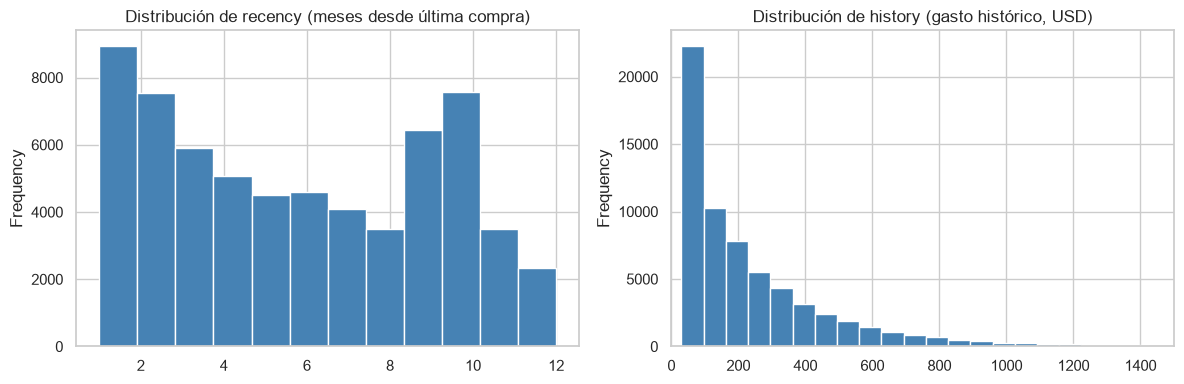

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["recency"].plot(kind="hist", bins=12, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de recency (meses desde última compra)")

df["history"].plot(kind="hist", bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Distribución de history (gasto histórico, USD)")
axes[1].set_xlim(0, 1500)
plt.tight_layout()
plt.show()

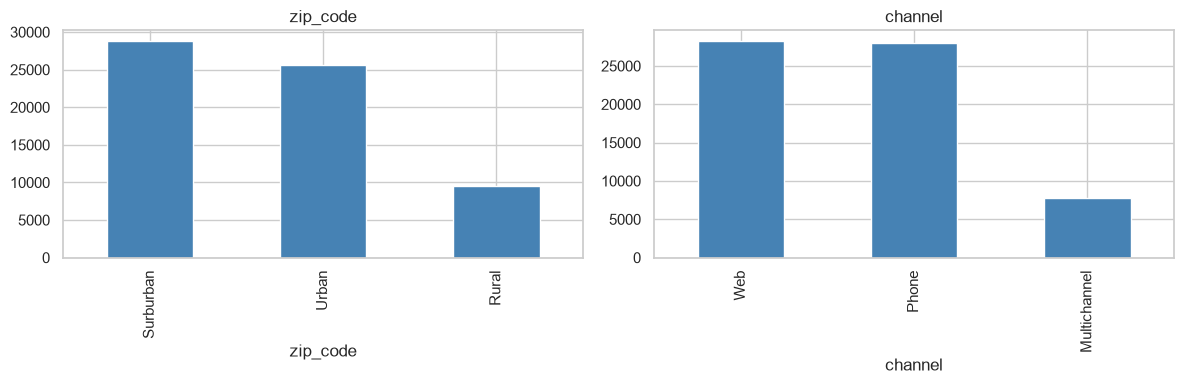

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["zip_code"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("zip_code")

df["channel"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("channel")
plt.tight_layout()
plt.show()

## Conclusiones del EDA

1. El dataset tiene 64,000 clientes, con un treatment desbalanceado
   (~67% tratados / ~33% control) que justifica usar X-Learner además de
   T-Learner.
2. `conversion` es un evento raro (~0.9%), lo que exige estratificar el split
   por treatment y outcome a la vez para no obtener test sets ruidosos.
3. La diferencia de conversión bruta entre tratados y control (~0.8pp) es el
   punto de partida (ATE poblacional), pero el objetivo de este proyecto es ir
   más allá y estimar ese efecto a nivel individual (CATE / uplift) usando las
   features del cliente.

Siguiente paso: `src/preprocessing.py` (split), `src/models.py` (S/T/X-Learner)
y `src/evaluation.py` (AUUC, Qini y comparación contra baselines).